In [1]:
%matplotlib inline

# Resource estimation for X-ray absorption and photodynamic therapy

Spectroscopy is an indispensible measurement technique in chemistry and
physics, providing fundamental insights into the structure and dynamics
of molecules and materials. However, to extract these insights, it is
often necessary to use simulations to interpret the experimentally
measured spectra. In practice, this requires exciting the system with an
external electromagnetic field\-\--for example, visible light, or
X-rays\-\--and then simulating how the system\'s quantum state evolves
over time in response to that, described by its Hamiltonian. On
classical computers, this is notoriously expensive. The computational
resources required to accurately model the excited states of a complex
molecule or material scale exponentially with system size, often pushing
even the most powerful supercomputers to their breaking point.

Can quantum computers do better?

<figure>
<img src='https://blog-assets.cloud.pennylane.ai/demos/tutorial_resource_estimation_spectroscopy/main/_assets/images/pennylane-demo-resource-estimation-spectroscopy-open-graph.png' alt='' style='display:block; margin:auto; width:50%;'/>
</figure>

In this demo, we answer that question by using PennyLane\'s resource
[estimator](https://docs.pennylane.ai/en/stable/code/qml_estimator.html#module-)
to directly calculate the requirements for two distinct algorithmic
approaches. Specifically, we calculate the resources for Trotter-based
time evolution for X-Ray Absorption Spectroscopy (XAS) and
Qubitization-based spectral filtering for Photodynamic Therapy (PDT). By
estimating the costs of these algorithms now, we can best prepare them
for execution on future fault-tolerant hardware.

## Simulating Spectroscopy on a Quantum Computer

Our first challenge is to translate a physical spectroscopy experiment
into a simulation performed with a quantum circuit.

Regardless of the specific spectroscopy being analyzed, whether it is
X-ray Absorption Spectroscopy (XAS), Vibrational Spectroscopy, or
Electron Energy Loss Spectroscopy, the core goal is the same:
calculating the time-domain correlation function, $\tilde{G}(t)$.

To measure this observable on a quantum computer, we rely on a standard
algorithmic template called the **Hadamard Test**.

<figure>
<img src='https://blog-assets.cloud.pennylane.ai/demos/tutorial_resource_estimation_spectroscopy/main/_assets/images/global_circuit.png' alt='' style='display:block; margin:auto; width:50%;'/>
<figcaption>Figure 1: <em>Circuit for XAS Simulation</em></figcaption>
</figure>

As we will see, the dominant cost in this circuit comes from the
controlled time evolution block, the efficiency of which dictates the
feasibility of our algorithm. This cost is set by the physics of the
specific spectroscopy we are after, as well as the details of our
implementation strategy.

While the physical problem of interest dictates the type of Hamiltonian
we must use (such as electronic, vibrational), we have significant
freedom to optimize the implementation. For example, we can choose
between different Hamiltonian representations, as well as the algorithms
for actually performing time evolution, like Trotterization or
[qubitization](https://pennylane.ai/qml/demos/tutorial_qubitization).

We begin with the example of [X-ray Absorption Spectroscopy
(XAS)](https://pennylane.ai/qml/demos/tutorial_xas), using PennyLane\'s
resource
[estimator](https://docs.pennylane.ai/en/stable/code/qml_estimator.html#module-)
to quantify the resource requirements.

## X-Ray Absorption Spectroscopy

[XAS](https://pennylane.ai/qml/demos/tutorial_xas) is a spectroscopic
method used to study the electronic and local structural environment of
specific elements within a material, by probing core-level electron
excitations. For this simulation, we follow the algorithm established in
Fomichev et al. (2025), which utilizes the [Compressed
Double-Factorization
(CDF)](https://pennylane.ai/qml/demos/tutorial_how_to_build_compressed_double_factorized_hamiltonians)
representation of the electronic Hamiltonian combined with
Trotterization.

To benchmark this approach, we focus on **4-iodo-2-methylphenol (IMePh, $\mathrm{C_7H_7IO}$)** molecule. IMePh has 110 electrons and 74 spatial MOs in STO-3G. The XAS active space targets iodine-centred core and valence excitations, sweeping from 10 to 30 orbitals.

The first step to determining the resources for this simulation is to
define the Hamiltonian. Luckily, it turns out that the resource
requirements for the simulation only depend on high-level attributes of
the Hamiltonian, specifically the number of orbitals and the number of
CDF fragments it was factorized into, rather than on the values of the
one- and two-electron integrals themselves. This makes our job
considerably simpler! It means that we can bypass the tedious
construction of the exact Hamiltonian, and instead use those two
high-level attributes to define a specialized [compact
Hamiltonian](https://docs.pennylane.ai/en/stable/code/api/pennylane.estimator.compact_hamiltonian.CDFHamiltonian.html)
representation offered by PennyLane. Creating and using the compact
Hamiltonian is much simpler, and it still provides the high accuracy we
need for our resource estimation. In this case, we adopt the commonly
used rule of thumb that the number of fragments needed for a
high-fidelity CDF factorization is roughly equal to the number of
spatial orbitals in the Hamiltonian.


In [2]:
import pennylane.estimator as qre

# 4-iodo-2-methylphenol (IMePh): C7H7IO
# Molecular formula: 7C + 7H + 1I + 1O → 110 electrons, 74 MOs in STO-3G.
# XAS targets iodine-centred core/valence excitations.
# We sweep over chemically relevant active space sizes.
# num_fragments is set equal to num_orbitals (standard CDF rule of thumb).
active_spaces = [10, 14, 18, 22, 26, 30]  # number of spatial orbitals
imeph_ham = [qre.CDFHamiltonian(num_orbitals=i, num_fragments=i) for i in active_spaces]


# Trotterization

With the Hamiltonian defined, we move to the time evolution. This
requires determining the total time of evolution and the number of
Trotter steps needed to keep the Trotter error within our pre-determined
bounds.

Following the analysis in Fomichev et al. (2025), we adopt a $2^{nd}$
order [Trotter-Suzuki product
formula](https://pennylane.ai/codebook/hamiltonian-simulation/trotterization).
The total simulation time is determined by the desired spectral
resolution, while the time step $\Delta t$ is derived from the error
budget.


In [3]:
import numpy as np

eta = 0.05   # Lorentzian width (experimental broadening) in Hartree
jmax = 100   # Number of time points
# For IMePh, iodine core/valence excitations span a broader energy range
# than light-atom molecules. Hnorm ~ 5.0 Ha covers the relevant I-edge XAS window.
Hnorm = 5.0  # Effective spectral range in Hartree

tau = np.pi / (2 * Hnorm)   # Sampling interval
trotter_error = 1            # Trotter error constraint in Hartree
delta = np.sqrt(eta / trotter_error)  # Trotter step size
num_trotter_steps = int(
    np.ceil(2 * jmax + 1) * tau / delta
)  # Number of Trotter steps for the longest time evolution


# XAS Circuit Construction

Having established the Hamiltonian structure and the Trotter step count,
we are now ready to estimate resources for the complete algorithm.

We assemble the complete XAS workflow as shown in the Hadamard test
circuit, by combining state preparation, the Hadamard test structure,
and controlled time evolution.

For the initial state preparation, we adopt the **Sum of Slaters**
method, which prepares in the quantum register an approximation to the
ground state wavefunction, obtained by discarding Slater determinants
below a coefficient tolerance. For this demo, we assume a truncation
level that yields $1 \times 10^4$ surviving determinants
(`num_slaters=1e4`). The cost of this approach depends on two major
subroutines: [QROM](pennylane.estimator.templates.QROM) to load the
determinants, and
[QROMStatePreparation](pennylane.estimator.templates.QROMStatePreparation)
to prepare the superposition.


In [4]:
def xas_circuit(hamiltonian, num_trotter_steps, measure_imaginary=False, num_slaters=1e4):

    # State preparation
    num_qubits = int(np.ceil(np.log2(num_slaters)))
    qre.QROMStatePreparation(
        num_state_qubits=num_qubits,
    )
    qre.QROM(num_bitstrings=2**num_qubits, size_bitstring=num_qubits, select_swap_depth=1)

    # Hadamard and S gates
    qre.Hadamard()

    if measure_imaginary:
        qre.Adjoint(qre.S())

    # Controlled time evolution
    qre.Controlled(
        qre.TrotterCDF(hamiltonian, num_trotter_steps, order=2),
        num_ctrl_wires=1,
        num_zero_ctrl=0,
    )

    qre.Hadamard()

# Estimating the Resources

With the circuit fully defined, we turn to resource estimation. Before
generating counts, however, we must select an implementation strategy
for the rotation gates, as this choice heavily influences the final
resource overhead.

By default, PennyLane\'s
[estimator](https://docs.pennylane.ai/en/stable/code/qml_estimator.html#module-)
provides the resources for rotation gate synthesis using
Repeat-Until-Success circuits, which decompose rotations into sequences
of probabilistic T-gates. While effective for general circuits, the
algorithm in Fomichev et al. (2025) used instead the [phase gradient
method](https://pennylane.ai/compilation/phase-gradient/) proposed by
Craig Gidney.

The phase gradient trick is algorithmically superior for this
application because it allows us to implement rotations with
deterministic cost using arithmetic, rather than relying on
probabilistic synthesis sequences. This results in better scaling as the
precision requirements increase. This method relies on a specific
resource state (the phase gradient state) that encodes phase information
in its amplitudes. A unique mathematical property of this state is that
adding an integer \$k\$ to the register mathematically induces a phase
rotation of angle $\theta \propto k$. Therefore, the cost of a rotation
becomes identical to the cost of a quantum adder.

To adopt this more efficient strategy, we configure the estimator to use
the phase gradient trick with the use of a
[-](https://docs.pennylane.ai/en/stable/code/api/pennylane.estimator.resource_config.ResourceConfig.html#).


In [5]:
def single_qubit_rotation(precision):
    """Gidney-Adder based decomposition for single qubit rotations"""
    num_bits = int(np.ceil(np.log2(1 / precision)))
    return [
        qre.GateCount(
            qre.resource_rep(qre.SemiAdder, {"max_register_size": num_bits + 1})
        )
    ]

cfg = qre.ResourceConfig()
cfg.set_decomp(qre.RX, single_qubit_rotation)
cfg.set_decomp(qre.RY, single_qubit_rotation)
cfg.set_decomp(qre.RZ, single_qubit_rotation)
cfg.set_single_qubit_rot_precision(1e-3)

With the configuration set, we run the resource estimation by sweeping
over the different active-spaces of our Hamiltonian.


In [6]:
xas_resources = []
toffolis = []
qubits = []
for ham in imeph_ham:
    resource_counts = qre.estimate(xas_circuit, config=cfg)(
        hamiltonian=ham, num_trotter_steps=num_trotter_steps, measure_imaginary=False
    )
    xas_resources.append(resource_counts)
    toffolis.append(resource_counts.gate_counts["Toffoli"])
    qubits.append(resource_counts.total_wires)


Let\'s visualize how these initial estimates scale with the system size.


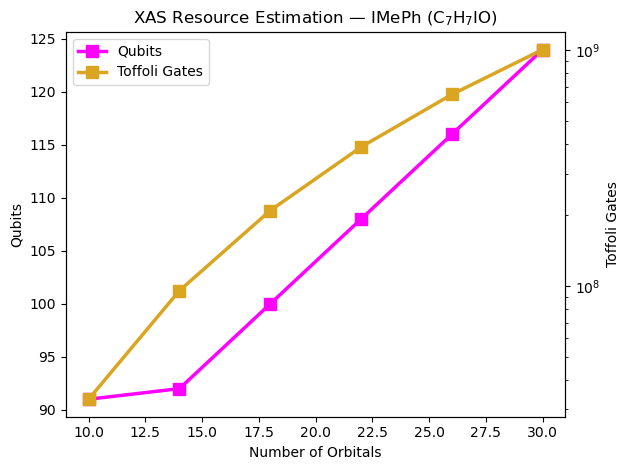

In [7]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

ax1.set_xlabel("Number of Orbitals")
ax1.set_ylabel("Qubits")
ax1.plot(active_spaces, qubits,
    "-s", color="fuchsia", label="Qubits", linewidth=2.5, markersize=8,
)
ax1.tick_params(axis="y")

ax2 = ax1.twinx()
ax2.set_ylabel("Toffoli Gates")
ax2.set_yscale("log")
ax2.plot(active_spaces, toffolis,
    "-s", color="goldenrod", label="Toffoli Gates", linewidth=2.5, markersize=8,
)
ax2.tick_params(axis="y")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.title(r"XAS Resource Estimation — IMePh ($\mathrm{C_7H_7IO}$)")
fig.tight_layout()
plt.show()


These results highlight that while qubit requirements (\~100) are
plausible for early fault-tolerant devices, the gate requirements pose a
challenge, as the complexity approaches $10^9$ Toffolis.

Notice that these are estimates for a single shot; the total cost for
the full algorithm will scale linearly with the number of samples
required, amplifying the gate costs even further.

However, we can do better.

# Optimizing the Estimates

We optimize the resource estimation by overriding the default
decompositions in
[estimator](https://docs.pennylane.ai/en/stable/code/qml_estimator.html#module-)
with specialized, high-performance subroutines tailored for this
algorithm.

## Optimization 1: Efficient Orbital Basis Transformation

In the Compressed Double Factorization (CDF) framework, the Hamiltonian
is decomposed into a sum of terms, where each term is diagonal in a
specific, rotated orbital basis. To simulate time evolution, the quantum
circuit must repeatedly transform the system\'s state into these
different bases.

In PennyLane, this basis change is modelled by the `BasisRotation`
operator. By default, the estimator computes its resources using a
standard decomposition strategy,

Here, we replace the generic decomposition with the specialized,
lower-cost circuit described in [Kivlichan et al.
(2018)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.120.110501).


In [8]:
def basis_rotation_cost(dim):
    """Custom basis rotation decomposition from Kivlichan et al. (2018)"""

    counts = dim * (dim - 1) / 2

    ops_data = [
        (qre.RZ, dim, None),
        (qre.RX, counts, None),
        (qre.RY, counts, None),
        (qre.Hadamard, 4 * counts, None),
        (qre.S, counts, None),
        (qre.Adjoint, counts, {"base_cmpr_op": qre.resource_rep(qre.S)}),
        (qre.CNOT, 2 * counts + dim, None),
    ]

    return [
        qre.GateCount(qre.resource_rep(op, params or {}), count)
        for op, count, params in ops_data
    ]


cfg.set_decomp(qre.BasisRotation, basis_rotation_cost)

toffolis_opt1 = []
for ham in imeph_ham:
    res = qre.estimate(xas_circuit, config=cfg)(
        hamiltonian=ham, num_trotter_steps=num_trotter_steps, measure_imaginary=False
    )
    toffolis_opt1.append(res.gate_counts["Toffoli"])

# Optimization 2: Double Phase Trick

Second, we implement the double phase trick for the Controlled-RZ (CRZ)
gates. As described in Section III.A of Fomichev et al. (2025), this
optimization reduces the cost of the controlled rotations inside the
Trotter steps by replacing each controlled rotation by one uncontrolled
rotation and two CNOT gates.


In [9]:
def custom_CRZ_decomposition(precision):
    """Decomposition of CRZ gate using double phase trick"""
    rz = qre.resource_rep(
        qre.RZ, {"precision": precision}
    )  # resource representation of RZ
    cnot = qre.resource_rep(qre.CNOT)

    return [qre.GateCount(cnot, 2), qre.GateCount(rz, 1)]


cfg.set_decomp(qre.CRZ, custom_CRZ_decomposition)

toffolis_final = []
for ham in imeph_ham:
    res = qre.estimate(xas_circuit, config=cfg)(
        hamiltonian=ham, num_trotter_steps=num_trotter_steps, measure_imaginary=False
    )
    toffolis_final.append(res.gate_counts["Toffoli"])

Let\'s visualize the cumulative impact of our optimizations:


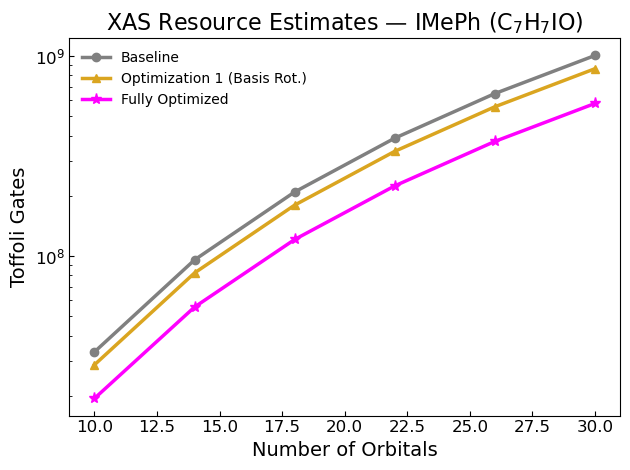

In [10]:
import matplotlib.pyplot as plt

plt.plot(active_spaces, toffolis, "o-", label="Baseline", color="gray", linewidth=2.5)
plt.plot(active_spaces, toffolis_opt1,
    "^-", label="Optimization 1 (Basis Rot.)", color="goldenrod", linewidth=2.5,
)
plt.plot(active_spaces, toffolis_final,
    "*-", label="Fully Optimized", color="fuchsia", linewidth=2.5, markersize=8,
)

plt.xlabel("Number of Orbitals", fontsize=14)
plt.ylabel("Toffoli Gates", fontsize=14)
plt.yscale("log")
plt.tick_params(axis="both", which="both", direction="in", labelsize=12)
plt.title(r"XAS Resource Estimates — IMePh ($\mathrm{C_7H_7IO}$)", fontsize=16)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

The plot illustrates the effectiveness of our optimization strategy. We
observe a consistent reduction in resource requirements as we apply each
layer of optimization. The efficient orbital rotation provides
improvements compared to the baseline, and use of the double phase trick
further depresses the Toffoli count. This stepwise reduction validates
the importance of matching the gate synthesis strategy to specific
algorithmic requirements, engineering a lower simulation cost by
targeting dominant bottlenecks.

# Photodynamic Therapy Applications

Having shown how to estimate resources for an XAS spectroscopic
workflow, let\'s see how we can apply these tools to a different
application: **Photodynamic Therapy (PDT)**. Here, we need to estimate
the cumulative absorption for a strongly correlated photosensitizer
molecule.

This application requires a different algorithmic approach. In XAS, we
simulated the system\'s time evolution using Trotterization to recover
the full spectrum. In PDT, we will instead employ a spectral filtering
approach to directly read out how much of the spectral internsity falls
within a predetermined window (typically 700--850 nm).

To do the filtering, we will use [generalized quantum signal processing
(GQSP)](https://pennylane.ai/qml/demos/tutorial_estimator_hamiltonian_simulation_gqsp),
combining it with a qubitization-based time evolution implementation.
Specifically, we will use a walk operator constructed from the tensor
hypercontracted Hamiltonian, which allows for a highly compact block
encoding. As with XAS, we can use the [compact
Hamiltonian](https://docs.pennylane.ai/en/stable/code/api/pennylane.estimator.compact_hamiltonian.THCHamiltonian.html)
representation to skip the expensive Hamiltonian construction. As an
example, let\'s use IMePh ($\mathrm{C_7H_7IO}$), a halogenated phenol with
photosensitizer potential. Its Hamiltonian parameters are estimated from
molecular properties (see code cell below for details).


In [11]:
# IMePh PDT Hamiltonian parameters (estimated from molecular properties):
# - num_orbitals=13: aromatic pi MOs (6) + O lone pairs (2) + I 5p (3) + sigma (2)
# - tensor_rank=26: standard THC rule of thumb (2 * num_orbitals)
# - one_norm=9.57 Ha: scaled from BODIPY (6.48 Ha, 11 orbitals) via
#   one_norm ~ C * num_orbitals^1.5, with a 1.15x correction for iodine's
#   heavier two-electron integral contributions.
imeph_pdt_ham = qre.THCHamiltonian(num_orbitals=13, tensor_rank=26, one_norm=9.57)


We now construct the [walk operator from the
Hamiltonian](https://pennylane.ai/qml/demos/tutorial_re_for_qubitizedQPE)
using the
[QubitizeTHC](https://docs.pennylane.ai/en/stable/code/api/pennylane.estimator.templates.QubitizeTHC.html)
template. For comprehensive details on how to construct and configure
this operator, we recommend the [Qubit and Gate Trade-offs in Qubitized
Quantum Phase
Estimation](https://pennylane.ai/qml/demos/tutorial_re_for_qubitizedQPE)
demo. Let\'s define the precision parameters based on the error budget
from Zhou et al., and construct the walk operator accordingly:


In [12]:
error = 0.0016  # Error budget in Hartree (chemical accuracy, same as BODIPY)
n_coeff = int(
    np.ceil(2.5 + np.log2(10 * imeph_pdt_ham.one_norm / error))
)  # Coefficient precision
n_angle = int(
    np.ceil(
        5.652 + np.log2(10 * imeph_pdt_ham.one_norm * 2 * imeph_pdt_ham.num_orbitals / error)
    )
)  # Rotation angle precision

prep_op = qre.PrepTHC(imeph_pdt_ham, coeff_precision=n_coeff, select_swap_depth=4)
select_op = qre.SelectTHC(imeph_pdt_ham, rotation_precision=n_angle, num_batches=5)
walk_op = qre.QubitizeTHC(imeph_pdt_ham, prep_op=prep_op, select_op=select_op)


Next, we need to set up the GQSP parameters to construct the spectral
filter. The filter is defined by a polynomial, the degree of which
determines the sharpness of the filter. We set the polynomial degree
using Figure 7 from Zhou et al. (2025), which relates the degree to the
desired spectral resolution.


In [13]:
def polynomial_degree(one_norm):
    """Calculate polynomial degree parameters from Zhou et al. (2025).
    The spectral window (700-850 nm) and fit coefficients are kept from
    the BODIPY reference, as IMePh is also a visible-light photosensitizer
    candidate targeting a similar therapeutic wavelength range.
    """
    e_hi = 0.0701  # Hartree (upper edge of spectral window)
    e_lo = 0.0507  # Hartree (lower edge of spectral window)
    degree_hi  = int(np.ceil(4.7571 * (one_norm + e_hi) / 0.01 + 321.2051))
    degree_low = int(np.ceil(4.7571 * (one_norm + e_lo) / 0.01 + 321.2051))
    return degree_hi, degree_low


We can now set up the resource estimation for the PDT algorithm by
defining the circuit as shown in Figure 2.

<figure>
<img src='https://blog-assets.cloud.pennylane.ai/demos/tutorial_resource_estimation_spectroscopy/main/_assets/images/gqsp_circuit.png' alt='' style='display:block; margin:auto; width:50%;'/>
<figcaption>Figure 2: <em>Threshold Projection
Circuit</em>.</figcaption>
</figure>


In [14]:
def pdt_circuit(walk_op, poly_degree_hi, poly_degree_low, num_slaters=1e4):
    num_qubits = int(np.ceil(np.log2(num_slaters)))
    qre.QROMStatePreparation(
        num_state_qubits=num_qubits,
        positive_and_real=False,
    )
    qre.QROM(num_bitstrings=2**num_qubits, size_bitstring=num_qubits, select_swap_depth=1)

    # Hadamard
    qre.Hadamard()

    # GQSP Spectral Filter
    qre.GQSP(walk_op, d_plus=poly_degree_hi)
    qre.GQSP(walk_op, d_plus=poly_degree_low)

    # Multi-Controlled-X
    qre.MultiControlledX(
        num_ctrl_wires=2,
        num_zero_ctrl=1,
        wires=[0,1,2]
    )

    # Hadamard
    qre.Hadamard()

Now that we have prepared all the components, we can estimate the
resources necessary to calculate cumulative absorption via the PDT
algorithm:


In [15]:
qubits_pdt = []
toffolis_pdt = []

poly_deg_hi, poly_deg_low = polynomial_degree(
    imeph_pdt_ham.one_norm
)  # Calculate polynomial degree
resource_counts = qre.estimate(pdt_circuit, config=cfg)(
    walk_op, poly_deg_hi, poly_deg_low
)
print(resource_counts)


--- Resources: ---
 Total wires: 192
   algorithmic wires: 86
   allocated wires: 106
     zero state: 106
     any state: 0
 Total gates : 4.518E+8
   'Toffoli': 3.387E+7,
   'CNOT': 3.109E+8,
   'X': 1.315E+7,
   'Z': 2.942E+5,
   'S': 5.100E+5,
   'Hadamard': 9.304E+7


The estimated resources above reflect the IMePh active space (13 orbitals,
one\_norm $\approx 9.57$ Ha). Compared to BODIPY (177 qubits, $\sim 2 \times 10^7$
Toffoli gates), IMePh requires more resources due to its larger one\_norm
and orbital count. We encourage you to explore further by adjusting
`num\_orbitals`, `tensor\_rank`, and `one\_norm` as more accurate quantum
chemistry data for IMePh becomes available, or by tuning `select\_swap\_depth`
and `num\_batches` to trade qubits for gates.

# Conclusion

In this demo, we showed how to perform end-to-end resource estimation
for two distinct spectroscopic paradigms: the time-domain simulation of
X-ray absorption (XAS) and the spectral filtering approach for
photodynamic therapy (PDT).

While PennyLane\'s resource
[estimator](https://docs.pennylane.ai/en/stable/code/qml_estimator.html#module-)
was able to give us initial estimates with minimum input
information\-\--including only a high-level description of the
Hamiltonian!\-\--we also showed how versatile it can be. Moving beyond
the standard implementations, we were able to quickly and easily
implement algorithmic optimizations from the literature, namely the
phase gradient trick and a specialized basis rotation implementation,
and immediately see their impact on the resource counts.

This capability to get rough, black-box estimates quickly, combined with
being able to easily refine and improve them, is a fundamental design
principle behind resource estimation in PennyLane, where our goal is to
enable a broad range of researchers to design highly performant
algorithmic workflows for their chosen quantum applications.
